> Import Libraries

In [3]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from datetime import time
import random

# __<u>Bulk Data Processing__ of various __Solar Plants</u>__
Which includes:
- Insert bulk data as pd.DataFrame
- Identify appropriate and feasible solar plants by regional location
- Select only necessary columns
- Save each individual plant data into .csv files for further processing
- Visual observations

> **<u>Solar Plants Detailed Data</u>**
>> *Two Major Sites are listed as below:*
>>   * **Ansan-si, Gyeonggi-do** — 2 Solar Plants (C_scode: **414241001.0, 414241002.0**)
>>   * **Gyeongju-si, Gyeongsangbuk-do** — 9 Solar Plants (C_scode: **717800001.0 ~ 717800009.0**)

> Define Paths

In [ ]:
# Identify the path to the data directory (date-stamped folder for version control)
DataDirectory = f'../../Database/2026-06-15/'

In [5]:
# Output directory for preprocessed CSV files
outDataDirectory = DataDirectory + "Preprocessed/"
extDataDirectory = '../Export/Data/'

# Create the directory if it doesn't exist
if not os.path.exists(outDataDirectory):
    os.makedirs(outDataDirectory)

# Create data directory for preprocessed exports
if not os.path.exists(extDataDirectory):
    os.makedirs(extDataDirectory)

### __<u>PV Plants Data Analysis</u>__

In [52]:
# Load various Solar Plants data from compressed gzip CSV file
PV_data = pd.read_csv(f"{DataDirectory}tbl_pv_dat.gzip", compression="gzip")

In [53]:
# Preview the first and last few rows to inspect the data
pd.set_option('display.max_columns', 50)  # Adjust the number of columns displayed for better readability
PV_data

,D_date,C_scode,I_devno,F_acpower,F_hpower,F_dailypower,F_totpower,F_dcvolt,F_dcvolt1,F_dcvolt2,F_dcvolt3,F_dccur,F_dccur1,F_dccur2,F_dccur3,F_dcpow,F_dcpow1,F_dcpow2,F_dcpow3,F_acvolt,F_rslvolt,F_stlvolt,F_trlvolt,F_accur,F_rpcur,F_spcur,F_tpcur,F_apvolt,F_bpvolt,F_cpvolt,F_apppow,F_actpow,F_reapow,F_pf,F_hz,F_rsghz,F_stghz,F_trghz,COL35,F_temp1,F_temp2,F_temp3,F_sp1,F_sp2,F_sp3,F_sp4,F_sp5
0,0001-01-01 00:00:00,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN
1,2021-01-01 00:00:03,414241001.0,1,0.00,NaN,NaN,48060.0,48.6,NaN,NaN,NaN,0.9,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,397.20,398.00,395.60,NaN,0.40,0.90,0.60,NaN,NaN,NaN,NaN,NaN,NaN,0.0,60.0,NaN,NaN,NaN,74.3,NaN,NaN,NaN,1.0,70.0,NaN,NaN,NaN
2,2021-01-01 00:00:38,717800001.0,1,0.00,NaN,NaN,24172.0,19.2,NaN,NaN,NaN,0.6,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,400.20,395.40,398.40,NaN,0.10,0.50,0.20,NaN,NaN,NaN,NaN,NaN,NaN,0.0,60.0,NaN,NaN,NaN,76.2,NaN,NaN,NaN,1.0,38.0,NaN,NaN,NaN
3,2021-01-01 00:00:40,717800003.0,1,0.00,NaN,NaN,33391.0,21.4,NaN,NaN,NaN,0.9,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,398.80,396.50,399.90,NaN,0.10,0.30,0.30,NaN,NaN,NaN,NaN,NaN,NaN,0.0,60.0,NaN,NaN,NaN,87.8,NaN,NaN,NaN,1.0,39.0,NaN,NaN,NaN
4,2021-01-01 00:00:48,717800005.0,1,0.00,NaN,NaN,35728.0,17.8,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,399.60,396.40,397.80,NaN,2.40,0.20,1.70,NaN,NaN,NaN,NaN,NaN,NaN,0.0,60.0,NaN,NaN,NaN,89.0,NaN,NaN,NaN,1.0,39.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36029109,2026-06-14 15:30:20,414770001.0,2,117.10,NaN,NaN,8254683.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,367.71,369.89,365.72,NaN,227.87,197.33,154.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36029110,2026-06-14 15:31:20,414770001.0,1,128.61,NaN,NaN,8579399.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,366.42,369.24,367.54,NaN,245.54,210.28,169.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36029111,2026-06-14 15:31:20,414770001.0,2,114.75,NaN,NaN,8254685.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,366.60,369.48,366.29,NaN,221.22,190.28,147.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36029112,2026-06-14 15:32:20,414770001.0,1,126.62,NaN,NaN,8579401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,369.55,369.39,366.93,NaN,248.50,215.02,159.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
# # Describe the dataset to get summary statistics and understand the distribution of numerical columns
# PV_data.describe().map(lambda x: f"{x:.2f}")

,C_scode,I_devno,F_acpower,F_hpower,F_dailypower,F_totpower,F_dcvolt,F_dcvolt1,F_dcvolt2,F_dcvolt3,F_dccur,F_dccur1,F_dccur2,F_dccur3,F_dcpow,F_dcpow1,F_dcpow2,F_dcpow3,F_acvolt,F_rslvolt,F_stlvolt,F_trlvolt,F_accur,F_rpcur,F_spcur,F_tpcur,F_apvolt,F_bpvolt,F_cpvolt,F_apppow,F_actpow,F_reapow,F_pf,F_hz,F_rsghz,F_stghz,F_trghz,COL35,F_temp1,F_temp2,F_temp3,F_sp1,F_sp2,F_sp3,F_sp4,F_sp5
count,36028700.00,36029114.00,25414217.00,5591104.00,5677276.00,36029114.00,33676834.00,86173.00,86173.00,1.00,33676834.00,86173.00,86173.00,1.00,33590662.00,1.00,1.00,1.00,1.00,36029114.00,36029114.00,36029114.00,1.00,36029114.00,36029114.00,36029114.00,10528726.00,10528726.00,10528726.00,7951336.00,10561138.00,7865164.00,23148109.00,33676834.00,1.00,1.00,1.00,9691842.00,13542439.00,7951336.00,7865164.00,20134396.00,20134396.00,10528726.00,10528726.00,1.00
mean,668998276.23,2.16,26.06,740.20,7420.94,684920.16,359.95,478.68,510.80,200.00,18.92,5.04,4.96,3.40,12.07,2000.00,2000.00,2000.00,220.00,196.87,196.34,225.78,5.00,33.47,32.29,32.03,119.55,120.10,119.51,9.29,8.64,0.00,29.07,44.74,60.00,60.00,60.00,104.57,26.52,32.85,32.77,1.31,142.33,0.49,0.10,1.40
std,111456079.33,2.25,86.76,20169.71,61699.20,1658400.27,325.01,196.44,219.04,nan,31.68,7.18,7.17,nan,19.86,nan,nan,nan,nan,197.85,197.26,183.04,nan,118.83,114.25,112.62,115.00,115.53,114.96,13.44,13.55,0.16,41.37,26.01,nan,nan,nan,15.92,19.60,1.10,0.32,0.67,179.48,0.50,11.76,nan
min,101381001.00,0.00,0.00,0.00,0.00,0.00,-3053.60,137.50,138.70,200.00,-71.59,0.00,0.00,3.40,-46.24,2000.00,2000.00,2000.00,220.00,-0.10,-0.10,-0.10,5.00,-1.00,-1.00,-1.00,0.00,0.00,0.00,-1.00,0.00,-12.40,-91.00,-60.07,60.00,60.00,60.00,0.00,0.00,-32.77,-32.77,0.00,0.00,0.00,0.00,1.40
25%,717800002.00,1.00,0.00,0.00,0.00,129458.00,0.00,232.60,234.10,200.00,0.00,0.00,0.00,3.40,0.00,2000.00,2000.00,2000.00,220.00,-0.10,-0.10,-0.10,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,5.55,60.00,60.00,60.00,108.30,1.00,32.77,32.77,1.00,0.00,0.00,0.00,1.40
50%,717800006.00,1.00,0.12,0.00,112.00,235219.17,554.30,600.60,645.90,200.00,1.50,1.10,1.10,3.40,0.50,2000.00,2000.00,2000.00,220.00,-0.10,-0.10,237.40,5.00,1.35,0.80,1.00,226.76,227.88,226.47,1.13,0.25,0.00,1.00,59.98,60.00,60.00,60.00,109.40,31.30,32.77,32.77,1.00,0.00,0.00,0.00,1.40
75%,717800008.00,2.00,21.60,7.00,330.00,369403.00,669.00,630.90,684.30,200.00,25.66,7.60,7.20,3.40,17.28,2000.00,2000.00,2000.00,220.00,399.00,397.10,398.10,5.00,28.60,27.78,29.20,230.90,231.97,230.81,15.02,13.23,0.00,81.30,60.00,60.00,60.00,60.00,109.90,40.30,32.77,32.77,2.00,284.00,1.00,0.13,1.40
max,717800010.00,10.00,1025.47,831349.00,831349.00,8579401.00,5200.00,735.10,787.20,200.00,227.90,32.90,32.60,3.40,6000.00,2000.00,2000.00,2000.00,220.00,428.60,414.60,418.70,5.00,1676.44,1636.06,1623.63,240.03,241.23,240.73,530.00,500.00,30.00,100.00,64.65,60.00,60.00,60.00,132.30,105.00,60.60,37.00,5.00,641.00,2.00,38074.00,1.40


In [55]:
# Check the data types of each column to understand the structure of the DataFrame
PV_data.dtypes

D_date           object
C_scode         float64
I_devno           int64
F_acpower       float64
F_hpower        float64
F_dailypower    float64
F_totpower      float64
F_dcvolt        float64
F_dcvolt1       float64
F_dcvolt2       float64
F_dcvolt3       float64
F_dccur         float64
F_dccur1        float64
F_dccur2        float64
F_dccur3        float64
F_dcpow         float64
F_dcpow1        float64
F_dcpow2        float64
F_dcpow3        float64
F_acvolt        float64
F_rslvolt       float64
F_stlvolt       float64
F_trlvolt       float64
F_accur         float64
F_rpcur         float64
F_spcur         float64
F_tpcur         float64
F_apvolt        float64
F_bpvolt        float64
F_cpvolt        float64
F_apppow        float64
F_actpow        float64
F_reapow        float64
F_pf            float64
F_hz            float64
F_rsghz         float64
F_stghz         float64
F_trghz         float64
COL35           float64
F_temp1         float64
F_temp2         float64
F_temp3         

In [56]:
# Mapping of original column names to new names
rename_map = {
    "D_date":    "DT",
    "F_acpower": "P_ac",
    "F_dcvolt":  "V_dc",
    "F_dccur":   "V_i",
    "F_dcpow":   "P_dc",
    "F_pf":      "PF",
    "F_hz":      "Freq",
}

PV_data = PV_data.rename(columns=rename_map)

In [58]:
PV_data["PV"] = PV_data["C_scode"].map(lambda x: f"{x:.0f}")

In [66]:
PV_data["PV"].unique()

array(['nan', '414241001', '717800001', '717800003', '717800005',
       '414241002', '717800004', '717800002', '717800007', '717800006',
       '717800009', '717800010', '717800008', '414770001', '101381001',
       '414271001'], dtype=object)

In [67]:
# ============================================================
# Selected Solar Plant Codes
# ============================================================

# SolarPlants located at Ansan-si, Gyeonggi-do
ansan_plants = [414241001, 414241002, 414770001, 414770002]

# SolarPlants located at Gyeongju-si, Gyeongsangbuk-do
gyeongju_plants = [717800001, 717800002, 717800003, 717800004,
                   717800005, 717800006, 717800007, 717800008,
                   717800009]

# Combine both areas into a single list of selected plant codes
PV_plants = ansan_plants + gyeongju_plants
PV_plants

[414241001,
 414241002,
 414770001,
 414770002,
 717800001,
 717800002,
 717800003,
 717800004,
 717800005,
 717800006,
 717800007,
 717800008,
 717800009]

In [68]:
# Columns to extract from the dataset
selected_columns = ["DT", "P_ac", "V_dc", "V_i", "P_dc", "PF", "Freq"]

# Loop through each selected plant code
for code in PV_plants:
    # Filter data for the current plant code
    # PV_Plant = PV_data[PV_data['PV'] == code]
    PV_Plant = PV_data[PV_data['PV'].astype(str) == str(code)]
    
    # Define the output file path
    save_path_out = os.path.join(outDataDirectory, f"PV_Plant_{int(code)}.csv")
    save_path_ext = os.path.join(extDataDirectory, f"PV_Plant_{int(code)}.csv")
    
    # Save the selected columns to CSV
    PV_Plant[selected_columns].to_csv(save_path_out, index=False)
    # PV_Plant[selected_columns].to_csv(save_path_ext, index=False)
    
    # Confirm the file has been saved
    print(f"Data for C_scode {int(code)}: Saved")

Data for C_scode 414241001: Saved
Data for C_scode 414241002: Saved
Data for C_scode 414770001: Saved
Data for C_scode 414770002: Saved
Data for C_scode 717800001: Saved
Data for C_scode 717800002: Saved
Data for C_scode 717800003: Saved
Data for C_scode 717800004: Saved
Data for C_scode 717800005: Saved
Data for C_scode 717800006: Saved
Data for C_scode 717800007: Saved
Data for C_scode 717800008: Saved
Data for C_scode 717800009: Saved


### __<u>Weather Data Analysis</u>__

In [70]:
# Load various Solar Plants data from compressed gzip CSV file
Weather_data = pd.read_csv(f"{DataDirectory}tbl_weather_dat.gzip", compression="gzip")

In [73]:
# Preview the first and last few rows to inspect the data
pd.set_option('display.max_columns', 50)  # Adjust the number of columns displayed
Weather_data

,C_scode,D_date,I_dev,I_comyn,F_temp,F_humidity,F_wind_direction,F_wind_speed,F_precipitation,F_insolation_slope,F_insolation_horizon,F_atmosp_press,F_dewpoint,F_dat1,F_dat2,F_dat3,F_dat4,F_dat5
0,3000,2023-02-22 17:28:09,1,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3000,2023-02-22 18:26:13,1,1,25.3,16.6,0.0,0.0,0.0,NaN,NaN,1025.0,-1.8,3.3,25.3,12.2,119.4,341.0
2,3000,2023-02-22 18:28:24,1,1,25.6,15.8,0.0,0.0,0.0,NaN,NaN,1024.9,-2.3,3.2,25.5,12.2,119.3,341.0
3,3000,2023-02-22 18:30:32,1,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3000,2023-02-22 18:34:40,1,-1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2423330,717804001,2025-04-15 10:56:07,3,1,10.1,54.9,265.9,2.8,67.4,1000.0,847.0,982.2,1.4,1000.0,25.3,847.0,0.0,NaN
2423331,717804001,2025-04-15 10:57:07,3,1,10.4,55.5,350.4,1.7,67.4,1005.0,851.0,982.1,1.8,1005.0,25.7,851.0,0.0,NaN
2423332,717804001,2025-04-15 10:58:07,3,1,10.4,55.0,238.8,1.4,67.4,1001.0,850.0,981.9,1.7,1001.0,26.2,850.0,0.0,NaN
2423333,717804001,2025-04-15 10:59:07,3,1,10.7,55.1,291.2,2.8,67.4,1008.0,858.0,982.2,2.1,1008.0,26.8,858.0,0.0,NaN


In [71]:
# Review types of each column in the Weather_data DataFrame to understand the structure and identify any necessary type conversions
Weather_data.dtypes

C_scode                   int64
D_date                   object
I_dev                     int64
I_comyn                   int64
F_temp                  float64
F_humidity              float64
F_wind_direction        float64
F_wind_speed            float64
F_precipitation         float64
F_insolation_slope      float64
F_insolation_horizon    float64
F_atmosp_press          float64
F_dewpoint              float64
F_dat1                  float64
F_dat2                  float64
F_dat3                  float64
F_dat4                  float64
F_dat5                  float64
dtype: object

In [74]:
# Mapping of original column names to new names
rename_map = {
    "D_date"            :       "DT",
    "F_temp"            :       "T_env",
    "F_humidity"        :       "RH_env",
    "F_wind_speed"      :       "V_wind",
    "F_precipitation"   :       "P_rain",
    "F_dewpoint"        :       "D_env",
    "F_atmosp_press"    :       "P_atm",
}

Weather_data = Weather_data.rename(columns=rename_map)

In [75]:
Weather_data["PV"] = Weather_data["C_scode"].map(lambda x: f"{x:.0f}")

In [76]:
Weather_data["PV"].unique()

array(['3000', '414244001', '626394001', '717804001'], dtype=object)

In [79]:
Weather_data

,C_scode,DT,I_dev,I_comyn,T_env,RH_env,F_wind_direction,V_wind,P_rain,F_insolation_slope,F_insolation_horizon,P_atm,D_env,F_dat1,F_dat2,F_dat3,F_dat4,F_dat5,PV
0,3000,2023-02-22 17:28:09,1,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3000
1,3000,2023-02-22 18:26:13,1,1,25.3,16.6,0.0,0.0,0.0,NaN,NaN,1025.0,-1.8,3.3,25.3,12.2,119.4,341.0,3000
2,3000,2023-02-22 18:28:24,1,1,25.6,15.8,0.0,0.0,0.0,NaN,NaN,1024.9,-2.3,3.2,25.5,12.2,119.3,341.0,3000
3,3000,2023-02-22 18:30:32,1,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3000
4,3000,2023-02-22 18:34:40,1,-1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2423330,717804001,2025-04-15 10:56:07,3,1,10.1,54.9,265.9,2.8,67.4,1000.0,847.0,982.2,1.4,1000.0,25.3,847.0,0.0,NaN,717804001
2423331,717804001,2025-04-15 10:57:07,3,1,10.4,55.5,350.4,1.7,67.4,1005.0,851.0,982.1,1.8,1005.0,25.7,851.0,0.0,NaN,717804001
2423332,717804001,2025-04-15 10:58:07,3,1,10.4,55.0,238.8,1.4,67.4,1001.0,850.0,981.9,1.7,1001.0,26.2,850.0,0.0,NaN,717804001
2423333,717804001,2025-04-15 10:59:07,3,1,10.7,55.1,291.2,2.8,67.4,1008.0,858.0,982.2,2.1,1008.0,26.8,858.0,0.0,NaN,717804001


In [82]:
# ============================================================
# Selected Weather Station Codes
# ============================================================

# Weather stations located at Ansan-si, Gyeonggi-do
ansan_weather = [414244001]

# Weather stations located at Gyeongju-si, Gyeongsangbuk-do
gyeongju_weather = [717804001]

# Combine both areas into a single list of selected plant codes
Weather_areas = ansan_weather + gyeongju_weather
Weather_areas

[414244001, 717804001]

In [83]:
# Columns to extract from the dataset
weather_selected_columns = ["DT", "T_env", "RH_env", "V_wind", "P_rain", "D_env", "P_atm"]

# Loop through each selected weather station code
for code in Weather_areas:
    # Filter data for the current weather station code
    Weather_Station = Weather_data[Weather_data['PV'].astype(str) == str(code)]
    
    # Define the output file path
    save_path_out = os.path.join(outDataDirectory, f"Weather_Station_{int(code)}.csv")
    save_path_ext = os.path.join(extDataDirectory, f"Weather_Station_{int(code)}.csv")
    
    # Save the selected columns to CSV
    Weather_Station[weather_selected_columns].to_csv(save_path_out, index=False)
    # Weather_Station[weather_selected_columns].to_csv(save_path_ext, index=False)
    
    # Confirm the file has been saved
    print(f"Data for Weather Station {int(code)}: Saved")

Data for Weather Station 414244001: Saved
Data for Weather Station 717804001: Saved


>> Adding more Weather data

In [18]:
import pandas as pd

years = [2021, 2022, 2023, 2024]

Site02_Weather_data_2021_2024 = pd.concat(
    [
        pd.read_csv(f"{DataDirectory}tbl_gyeongju_pv_weather_{y}.gzip", compression="gzip")
        for y in years
    ],
    ignore_index=True,
)

Site02_Weather_data_2021_2024.columns.tolist()

['C_scode',
 'D_date',
 'I_devno',
 'F_totpower',
 'F_temp',
 'F_wind_speed',
 'F_humidity',
 'F_daylight',
 'F_solar_radiation',
 'F_snowfall',
 'F_total_cloud_cover',
 'C_cloud_pattern',
 'C_visibility',
 'F_ground_state',
 'F_ground_temp',
 'F_precipitation',
 'F_wind_direction']

In [19]:
Site02_Weather_data_2021_2024["PV"] = Site02_Weather_data_2021_2024["C_scode"].map(lambda x: f"{x:.0f}")
Site02_Weather_data_2021_2024["PV"].unique()

array(['717800010'], dtype=object)

In [21]:
# Mapping of original column names to new names
rename_map = {
    "D_date"            :       "DT",
    "F_temp"            :       "T_env",
    "F_humidity"        :       "RH_env",
    "F_wind_speed"      :       "V_wind",
    "F_precipitation"   :       "P_rain",
    "F_snowfall"        :       "D_env", 
    # "F_atmosp_press"    :       "P_atm", # Not available in all years, so commented out for consistency across datasets
}

In [22]:
Site02_Weather_data_2021_2024 = Site02_Weather_data_2021_2024.rename(columns=rename_map)

In [23]:
# Columns to extract from the dataset
weather_selected_columns = ["DT", "T_env", "RH_env", "V_wind", "P_rain", "D_env"]

In [25]:
ENV = Site02_Weather_data_2021_2024[weather_selected_columns]

C:\Users\rbmxu\AppData\Local\Temp\ipykernel_13640\4087810166.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ENV['DT'] = pd.to_datetime(ENV['DT'])


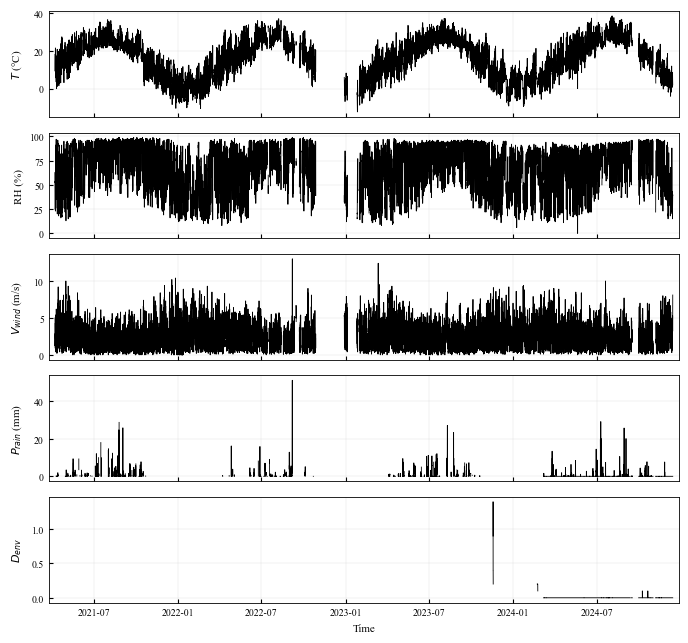

In [28]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---- IEEE-style rcParams ----
mpl.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Times New Roman', 'DejaVu Serif'],
    'font.size':        8,
    'axes.linewidth':   0.6,
    'lines.linewidth':  0.6,
    'xtick.direction':  'in',
    'ytick.direction':  'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'axes.grid':        True,
    'grid.linewidth':   0.3,
    'grid.alpha':       0.4,
})

# ---- Prepare & clean ----
ENV['DT'] = pd.to_datetime(ENV['DT'])
env = ENV.set_index('DT').sort_index()

# Drop physically impossible / empty records
# env = env[env['P_atm'] > 800]          # removes the 0-hPa startup garbage
env.loc[env['V_wind'] > 60, 'V_wind'] = pd.NA   # 60 m/s ~ hurricane; spikes above = sensor errors

cols   = ['T_env', 'RH_env', 'V_wind', 'P_rain', 'D_env']
labels = ['$T$ (°C)', 'RH (%)', '$V_{wind}$ (m/s)',
          '$P_{rain}$ (mm)', '$D_{env}$']

env_h = env[cols].resample('h').mean()

# ---- Figure: IEEE double-column width (7.16 in) ----
fig, axes = plt.subplots(len(cols), 1, figsize=(7.16, 6.5), sharex=True)

for ax, col, lab in zip(axes, cols, labels):
    ax.plot(env_h.index, env_h[col], color='black')
    ax.set_ylabel(lab, fontsize=8)
    ax.margins(x=0.01)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Time', fontsize=8)
fig.align_ylabels(axes)
fig.subplots_adjust(hspace=0.15, left=0.10, right=0.98, top=0.98, bottom=0.07)

# Save vector + high-res raster for submission
# fig.savefig('ENV_timeseries.pdf', bbox_inches='tight')
# fig.savefig('ENV_timeseries.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# Review types of each column in the Weather_data DataFrame to understand the structure and identify any necessary type conversions
Weather_data.dtypes
# Mapping of original column names to new names
rename_map = {
    "D_date"            :       "DT",
    "F_temp"            :       "T_env",
    "F_humidity"        :       "RH_env",
    "F_wind_speed"      :       "V_wind",
    "F_precipitation"   :       "P_rain",
    "F_dewpoint"        :       "D_env",
    "F_atmosp_press"    :       "P_atm",
}

Weather_data = Weather_data.rename(columns=rename_map)
Weather_data["PV"] = Weather_data["C_scode"].map(lambda x: f"{x:.0f}")
Weather_data["PV"].unique()
Weather_data
# ============================================================
# Selected Weather Station Codes
# ============================================================

# Weather stations located at Ansan-si, Gyeonggi-do
ansan_weather = [414244001]

# Weather stations located at Gyeongju-si, Gyeongsangbuk-do
gyeongju_weather = [717804001]

# Combine both areas into a single list of selected plant codes
Weather_areas = ansan_weather + gyeongju_weather
Weather_areas
# Columns to extract from the dataset
weather_selected_columns = ["DT", "T_env", "RH_env", "V_wind", "P_rain", "D_env", "P_atm"]

# Loop through each selected weather station code
for code in Weather_areas:
    # Filter data for the current weather station code
    Weather_Station = Weather_data[Weather_data['PV'].astype(str) == str(code)]
    
    # Define the output file path
    save_path_out = os.path.join(outDataDirectory, f"Weather_Station_{int(code)}.csv")
    save_path_ext = os.path.join(extDataDirectory, f"Weather_Station_{int(code)}.csv")
    
    # Save the selected columns to CSV
    Weather_Station[weather_selected_columns].to_csv(save_path_out, index=False)
    # Weather_Station[weather_selected_columns].to_csv(save_path_ext, index=False)
    
    # Confirm the file has been saved
    print(f"Data for Weather Station {int(code)}: Saved")